# <center>**Dimensionality Reduction and Unsupervised Clustering**</center>

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
formation_returns = pd.read_parquet('data/formation.parquet')

# choose random columns and visualize their distribution
random_stocks = formation_returns.sample(n=4, axis=1, random_state=42)
print(random_stocks.columns)

Index(['RVTY', 'TT', 'ADM', 'CASY'], dtype='str', name='Ticker')


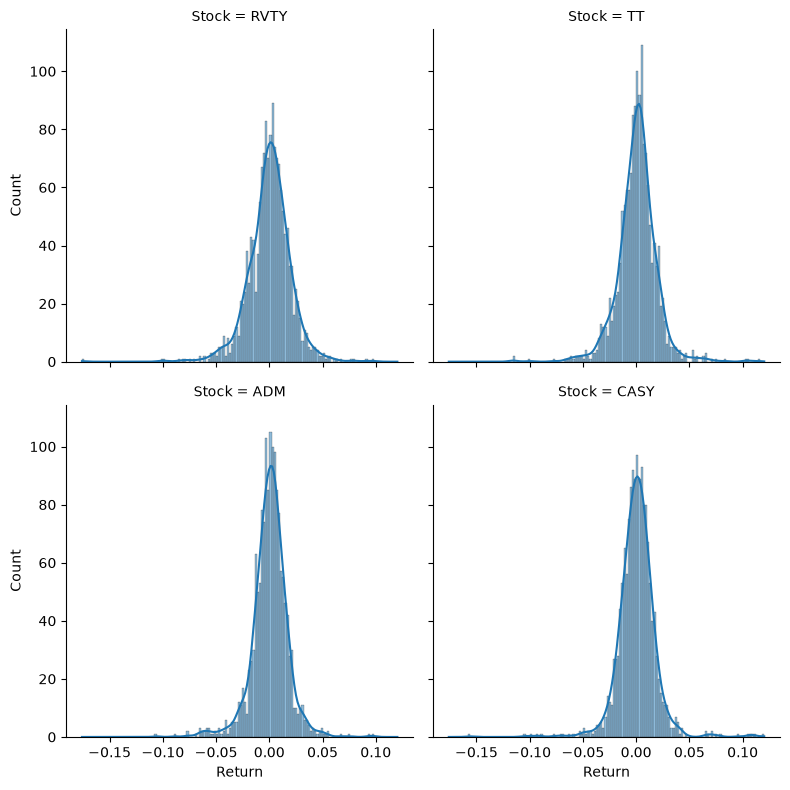

In [ ]:
# visualize their distribution
data = random_stocks.melt(
    var_name="Stock",
    value_name="Return"
)

sns.displot(
    data=data,
    x="Return",
    col="Stock",
    col_wrap=2,
    kde=True,
    height=4
)

plt.show()

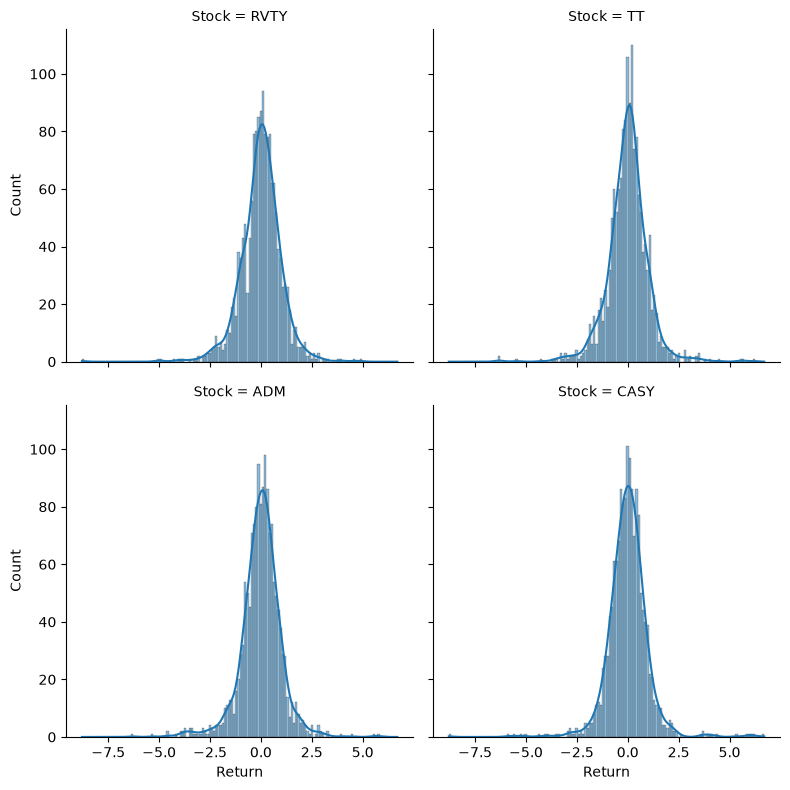

In [30]:
N_COMPONENTS = 50
scaler = StandardScaler()
pca = PCA(n_components=N_COMPONENTS)

dates = formation_returns['Date'] # dates cannot be scaled
X = formation_returns.select_dtypes(include='number')
scaled_returns = scaler.fit_transform(X)
pca_returns = pca.fit(scaled_returns)


# turn back to df to visualize distns
scaled_returns_df = pd.DataFrame(
    scaled_returns,
    columns=X.columns,
    index=formation_returns.index
)

# visualize their distribution
data = scaled_returns_df[['RVTY', 'TT', 'ADM', 'CASY']].melt(
    var_name="Stock",
    value_name="Return"
)

sns.displot(
    data=data,
    x="Return",
    col="Stock",
    col_wrap=2,
    kde=True,
    height=4
)

plt.show()

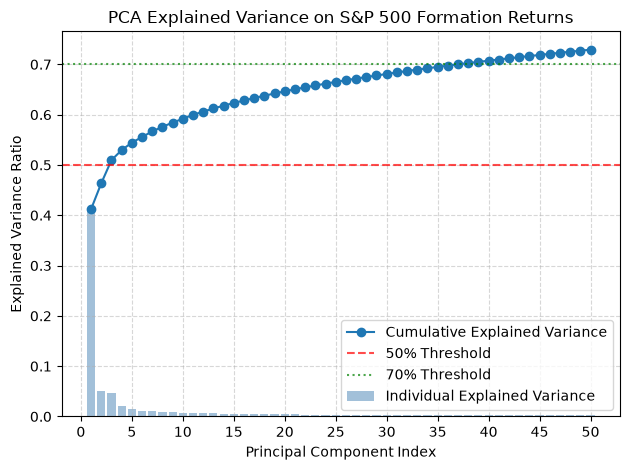

In [43]:
# get individual and cumulative explained variance ratio
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Bar chart of individual variance explained by each component
plt.bar(range(1, N_COMPONENTS + 1), explained_var, alpha=0.5, align='center',
        label='Individual Explained Variance', color='steelblue')

plt.plot(
    range(1, N_COMPONENTS + 1),
    cumulative_var,
    marker='o',
    label='Cumulative Explained Variance'
)

# Reference thresholds (e.g., 50% and 70% variance)
plt.axhline(y=0.50, color='red', linestyle='--', alpha=0.7, label='50% Threshold')
plt.axhline(y=0.70, color='green', linestyle=':', alpha=0.7, label='70% Threshold')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('PCA Explained Variance on S&P 500 Formation Returns')
plt.xticks(np.arange(0, N_COMPONENTS + 1, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [41]:
for threshold in [0.4, 0.5, 0.6, 0.7]:
    n_comp = np.argmax(cumulative_var >= threshold) + 1
    print(f"{threshold*100:.0f}% variance captured by the first {n_comp} components")

40% variance captured by the first 1 components
50% variance captured by the first 3 components
60% variance captured by the first 12 components
70% variance captured by the first 37 components


In [48]:
# Fit PCA with chosen number of components
N_SELECTED = 12
pca = PCA(n_components=N_SELECTED)
pca.fit(scaled_returns)

# Extract stock embeddings (Factor Loadings matrix)
# shape: (n_stocks, n_components)
stock_embeddings = pca.components_.T 
stock_names = scaled_returns_df.columns

print(f"Stock embeddings shape: {stock_embeddings.shape}")

# Fit DBSCAN, we start with eps=0.25 to 0.45, and min_samples=2 or 3
dbscan = DBSCAN(eps=0.40, min_samples=3, metric='cosine')
cluster_labels = dbscan.fit_predict(stock_embeddings)

# Create a DataFrame mapping Stock -> Cluster
clusters_df = pd.DataFrame({
    'Ticker': stock_names,
    'Cluster': cluster_labels
})

# Inspect cluster distribution
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

print(f"Total Clusters Found: {n_clusters}")
print(f"Stocks labeled as Noise/Outliers (-1): {n_noise} out of {len(stock_names)}")
print(f"Stocks assigned to valid clusters: {len(stock_names) - n_noise}")
print("\nCluster sizes:")
print(clusters_df[clusters_df['Cluster'] != -1]['Cluster'].value_counts())


Stock embeddings shape: (474, 12)
Total Clusters Found: 1
Stocks labeled as Noise/Outliers (-1): 0 out of 474
Stocks assigned to valid clusters: 474

Cluster sizes:
Cluster
0    474
Name: count, dtype: int64


Min Distance : 0.0018
Median Dist  : 0.9452
Max Distance : 1.7505


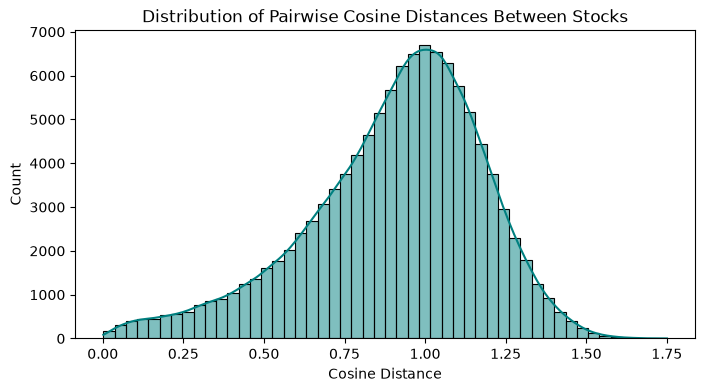

In [52]:
# Compute pairwise cosine distances
distances = pairwise_distances(stock_embeddings, metric='cosine')

# Extract upper triangle of distance matrix (excluding diagonal 0s)
upper_tri_distances = distances[np.triu_indices_from(distances, k=1)]

print(f"Min Distance : {upper_tri_distances.min():.4f}")
print(f"Median Dist  : {np.median(upper_tri_distances):.4f}")
print(f"Max Distance : {upper_tri_distances.max():.4f}")

# Plot distance distribution
plt.figure(figsize=(8, 4))
sns.histplot(upper_tri_distances, bins=50, kde=True, color='teal')
plt.title("Distribution of Pairwise Cosine Distances Between Stocks")
plt.xlabel("Cosine Distance")
plt.show()

In [51]:
# Optional but recommended: Standardize the embeddings across components
# so each principal component gets equal weighting in the distance metric
embeddings_scaled = scaler.fit_transform(stock_embeddings)

# Fit DBSCAN with tighter parameters
# If using embeddings_scaled with euclidean: eps ~ 1.0 to 1.8
# If using raw stock_embeddings with cosine: eps ~ 0.05 to 0.15
dbscan = DBSCAN(eps=1.2, min_samples=3, metric='euclidean')
cluster_labels = dbscan.fit_predict(embeddings_scaled)

clusters_df = pd.DataFrame({
    'Ticker': stock_names,
    'Cluster': cluster_labels
})

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

print(f"Total Clusters Found: {n_clusters}")
print(f"Stocks labeled as Noise (-1): {n_noise}")
print(f"Stocks in valid clusters: {len(stock_names) - n_noise}")
print("\nCluster Sizes:")
print(clusters_df[clusters_df['Cluster'] != -1]['Cluster'].value_counts())


Total Clusters Found: 19
Stocks labeled as Noise (-1): 371
Stocks in valid clusters: 103

Cluster Sizes:
Cluster
2     18
0     15
1      8
7      6
11     5
3      5
15     5
5      4
12     4
6      4
10     4
16     4
8      3
4      3
9      3
13     3
14     3
17     3
18     3
Name: count, dtype: int64


In [53]:
clusters_df.head()

,Ticker,Cluster
0,A,-1
1,AAPL,-1
2,ABBV,-1
3,ABT,-1
4,ACGL,-1


In [54]:
# Inspect tickers in the largest clusters
for cluster_id in [0, 1, 2, 3, 7]:
    tickers_in_cluster = clusters_df[clusters_df['Cluster'] == cluster_id]['Ticker'].tolist()
    print(f"\n--- Cluster {cluster_id} ({len(tickers_in_cluster)} stocks) ---")
    print(", ".join(tickers_in_cluster))


--- Cluster 0 (15 stocks) ---
AEE, AEP, ATO, AWK, CMS, D, DUK, ED, ES, EVRG, LNT, NI, SO, WEC, XEL

--- Cluster 1 (8 stocks) ---
ADI, AMAT, KLAC, LRCX, MCHP, SWKS, TER, TXN

--- Cluster 2 (18 stocks) ---
BAC, BNY, C, CFG, FITB, GS, HBAN, JPM, KEY, MS, MTB, NTRS, PNC, RF, STT, TFC, USB, WFC

--- Cluster 3 (5 stocks) ---
BKR, COP, HAL, SLB, XOM

--- Cluster 7 (6 stocks) ---
CPT, ESS, INVH, MAA, UDR, VMRK


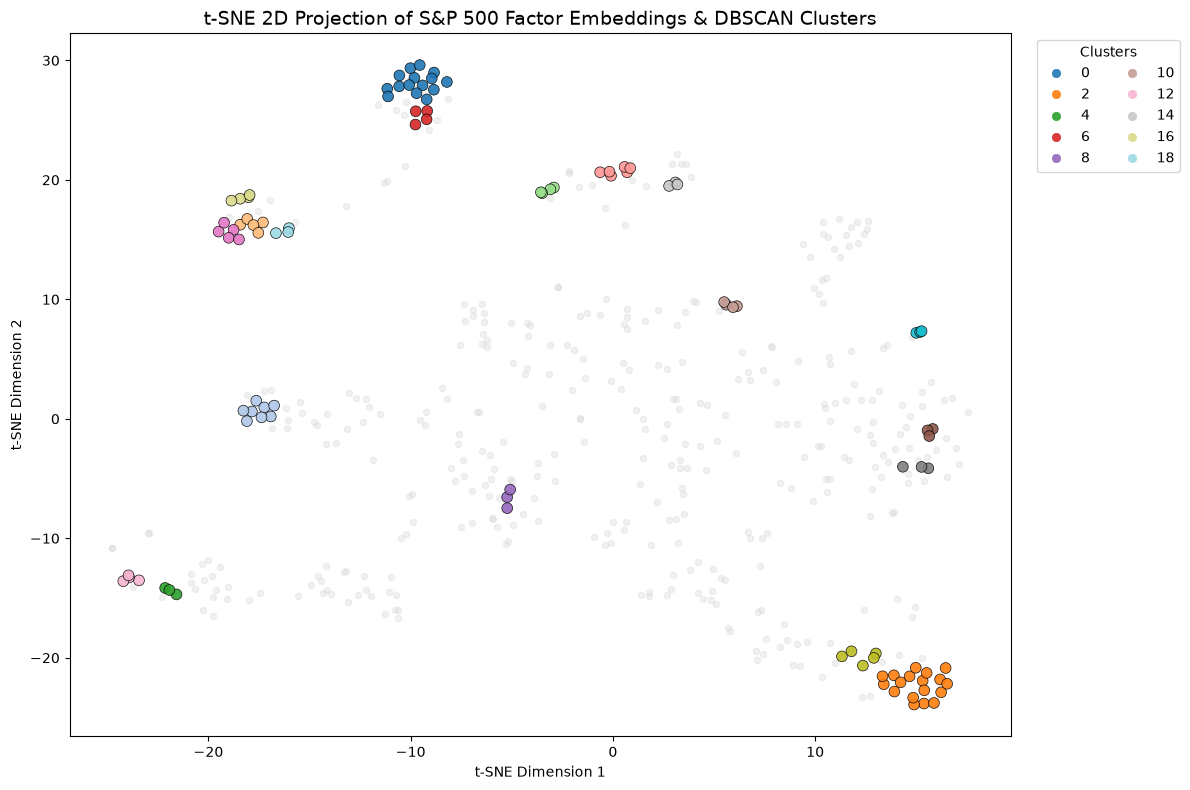

In [56]:
# Fit t-SNE to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_scaled)

clusters_df['TSNE_1'] = embeddings_2d[:, 0]
clusters_df['TSNE_2'] = embeddings_2d[:, 1]

plt.figure(figsize=(12, 8))

# Plot noise stocks in light grey
noise_mask = clusters_df['Cluster'] == -1
plt.scatter(clusters_df.loc[noise_mask, 'TSNE_1'], 
            clusters_df.loc[noise_mask, 'TSNE_2'], 
            c='lightgrey', alpha=0.3, s=20, label='Noise (-1)')

# Plot clustered stocks in color
valid_mask = ~noise_mask
scatter = plt.scatter(clusters_df.loc[valid_mask, 'TSNE_1'], 
                      clusters_df.loc[valid_mask, 'TSNE_2'], 
                      c=clusters_df.loc[valid_mask, 'Cluster'], 
                      cmap='tab20', alpha=0.9, s=60, edgecolors='k', linewidth=0.5)

plt.title('t-SNE 2D Projection of S&P 500 Factor Embeddings & DBSCAN Clusters', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


In [57]:
# Save only the valid clustered stocks for Phase 3
valid_clusters = clusters_df[clusters_df['Cluster'] != -1].copy()
valid_clusters.to_parquet('data/stock_clusters.parquet')
print(f"Saved {len(valid_clusters)} clustered stocks across {n_clusters} clusters to 'data/stock_clusters.parquet'")

Saved 103 clustered stocks across 19 clusters to 'data/stock_clusters.parquet'
